In [7]:
# Pickleball Technique Comparison using MediaPipe Pose

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np


# Helper functions
def calculate_angle(a, b, c):
    """Calculate angle between three points (in degrees) with b as vertex."""
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

def draw_pose_landmarks(image, landmarks, connections, color=(0, 255, 0)):
    for connection in connections:
        start_idx, end_idx = connection
        x1, y1 = landmarks[start_idx]
        x2, y2 = landmarks[end_idx]
        cv2.line(image, (x1, y1), (x2, y2), color, 2)
    for x, y in landmarks:
        cv2.circle(image, (x, y), 5, color, -1)

def extract_keypoints(results, image_shape):
    h, w, _ = image_shape
    keypoints = []
    for lm in results.pose_landmarks.landmark:
        keypoints.append((int(lm.x * w), int(lm.y * h)))
    return keypoints


In [13]:
# Load images
expert_path = "/Users/chang/Desktop/expert.png"  # replace with your image paths
student_path = "/Users/chang/Desktop/expert.png"
expert_img = cv2.imread(expert_path)
student_img = cv2.imread(student_path)




In [14]:
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils


I0000 00:00:1755236649.896243 5144815 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M4
W0000 00:00:1755236649.982864 5452429 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755236649.992437 5452430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [15]:
# Process expert image
expert_rgb = cv2.cvtColor(expert_img, cv2.COLOR_BGR2RGB)
expert_results = pose.process(expert_rgb)
expert_keypoints = extract_keypoints(expert_results, expert_img.shape)



In [16]:
# Process student image
student_rgb = cv2.cvtColor(student_img, cv2.COLOR_BGR2RGB)
student_results = pose.process(student_rgb)
student_keypoints = extract_keypoints(student_results, student_img.shape)




Joint Angle Comparisons:
elbow_right: Expert=137.4°, Student=137.4°, Diff=0.0°
shoulder_right: Expert=65.1°, Student=65.1°, Diff=0.0°
torso_tilt: Expert=82.7°, Student=82.7°, Diff=0.0°


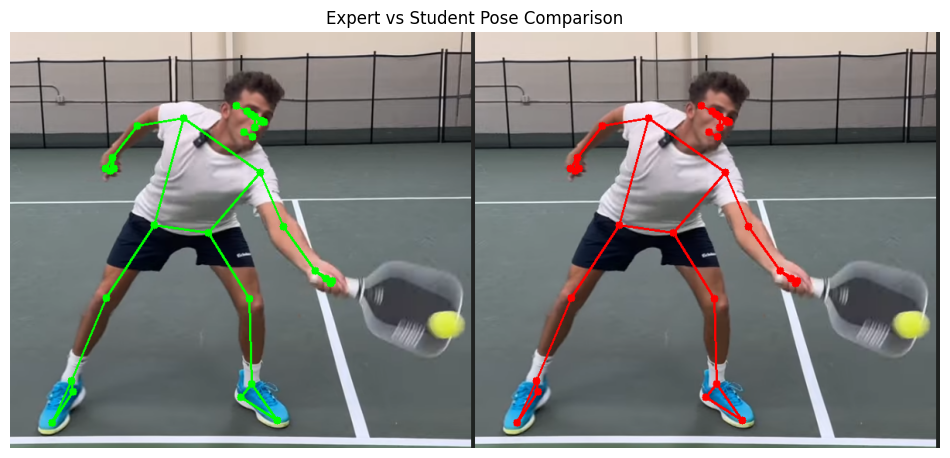

In [17]:




# Define key joints for angle analysis
JOINTS = {
    "elbow_right": (mp_pose.PoseLandmark.RIGHT_SHOULDER.value, mp_pose.PoseLandmark.RIGHT_ELBOW.value, mp_pose.PoseLandmark.RIGHT_WRIST.value),
    "shoulder_right": (mp_pose.PoseLandmark.RIGHT_HIP.value, mp_pose.PoseLandmark.RIGHT_SHOULDER.value, mp_pose.PoseLandmark.RIGHT_ELBOW.value),
    "torso_tilt": (mp_pose.PoseLandmark.LEFT_HIP.value, mp_pose.PoseLandmark.RIGHT_HIP.value, mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
}

# Compute angles
angle_diffs = {}
for name, (a_idx, b_idx, c_idx) in JOINTS.items():
    angle_expert = calculate_angle(expert_keypoints[a_idx], expert_keypoints[b_idx], expert_keypoints[c_idx])
    angle_student = calculate_angle(student_keypoints[a_idx], student_keypoints[b_idx], student_keypoints[c_idx])
    angle_diffs[name] = (angle_expert, angle_student, angle_student - angle_expert)

# Draw annotations
expert_vis = expert_img.copy()
student_vis = student_img.copy()
draw_pose_landmarks(expert_vis, expert_keypoints, mp_pose.POSE_CONNECTIONS, color=(0, 255, 0))
draw_pose_landmarks(student_vis, student_keypoints, mp_pose.POSE_CONNECTIONS, color=(0, 0, 255))

# Show side-by-side annotated images
combined = np.hstack((expert_vis, student_vis))
cv2.imwrite("comparison_output.png", combined)

# Print angle comparisons
print("\nJoint Angle Comparisons:")
for joint, (angle_expert, angle_student, diff) in angle_diffs.items():
    print(f"{joint}: Expert={angle_expert:.1f}°, Student={angle_student:.1f}°, Diff={diff:.1f}°")

# Optional: Show in notebook
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.title("Expert vs Student Pose Comparison")
plt.axis('off')
plt.show()
